In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error

In [110]:
df = pd.read_csv('/content/car_age_price.csv')

In [111]:
df.head()

,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [112]:
df.isnull().sum()

,0
Year,0
Price,0


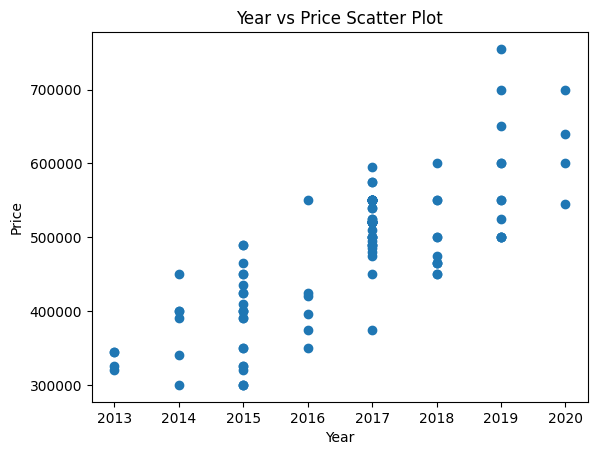

In [113]:
#data visualization --->  scatter plot

plt.scatter(df['Year'], df['Price'])
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Price Scatter Plot")
plt.show()


In [114]:
#seperate x and y
x = df[['Year']]
y = df['Price']

In [115]:
#train-test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [116]:
x_train.shape, x_test.shape,y_train.shape,y_test.shape

((89, 1), (23, 1), (89,), (23,))

In [117]:
#linear regression model

model = LinearRegression()

In [118]:
#making predictions
model.fit(x_train,y_train)

LinearRegression()

In [119]:
y_pred_le = model.predict(x_test)

In [120]:
y_pred_le

array([600775.91252081, 505558.77690466, 553167.34471273, 553167.34471273,
       553167.34471273, 410341.6412885 , 505558.77690466, 553167.34471273,
       600775.91252081, 600775.91252081, 315124.50567235, 505558.77690466,
       410341.6412885 , 648384.48032889, 553167.34471273, 600775.91252081,
       315124.50567235, 410341.6412885 , 505558.77690466, 505558.77690466,
       505558.77690466, 505558.77690466, 505558.77690466])

In [121]:
#evaluations

mse_le = mean_squared_error(y_pred_le,y_test)
print(mse_le)

4326906256.829671


In [122]:
rmse_le =root_mean_squared_error(y_pred_le,y_test)
rmse_le

65779.22359552195

In [123]:
r2_le = r2_score(y_test,y_pred_le)
r2_le

0.36759313425902185

In [124]:
#lasso regression model

lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)

Lasso(alpha=0.1)

In [125]:
y_pred_lasso = lasso.predict(x_test)

In [126]:
y_pred_lasso

array([600775.81201603, 505558.75884159, 553167.28542881, 553167.28542881,
       553167.28542881, 410341.70566715, 505558.75884159, 553167.28542881,
       600775.81201603, 600775.81201603, 315124.65249272, 505558.75884159,
       410341.70566715, 648384.33860324, 553167.28542881, 600775.81201603,
       315124.65249272, 410341.70566715, 505558.75884159, 505558.75884159,
       505558.75884159, 505558.75884159, 505558.75884159])

In [127]:
mse_lasso = mean_squared_error(y_pred_lasso,y_test)
mse_lasso

4326901608.19506

In [128]:
r2_lasso = r2_score(y_test,y_pred_lasso)
r2_lasso

0.36759381368868127

In [129]:
rmse_lasso =root_mean_squared_error(y_pred_lasso,y_test)
rmse_lasso

65779.18826038415

In [132]:
df_result = pd.DataFrame({
    'model':['linear regression','lasso'],
    'mse':[mse_le,mse_lasso],
    'r2':[r2_le,r2_lasso],
    'rmse':[rmse_le,rmse_lasso]
})

In [133]:
df_result

,model,mse,r2,rmse
0,linear regression,4.326906e+09,0.367593,65779.223596
1,lasso,4.326902e+09,0.367594,65779.188260


####best performing model is Lasso Regression

In [ ]:
# predict the possible price of a 2022 model second-handgrand i10

In [138]:
#using linear regression
model.predict([[2022]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([743601.61594504])

In [137]:
#using lasso regression
lasso.predict([[2022]])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


array([743601.39177768])

###conclusion

Based on the evaluation metrics, Lasso Regression performs slightly better than Linear Regression with marginally lower MSE and RMSE values and a slightly higher R² score. However, the performance difference is negligible because the dataset contains only one independent feature. Hence, both models perform almost equally well, with Lasso Regression being marginally better.